###  The Goal:
Given the **Title** and **Description** of any news article, predict which category it belongs to:
- **Category 1:** World
- **Category 2:** Sports
- **Category 3:** Business
- **Category 4:** Sci/Tech


## Step 1: Importing Libraries

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Step 2: Load and Explore the Datasets

We load the two CSV files provided:
- **`train.csv`**: Used to train our machine learning models (120,000 news articles).
- **`test.csv`**: Kept separate to test how well our model performs on unseen data (7,600 news articles).

Each file contains three columns:
1. `Class Index` (1 = World, 2 = Sports, 3 = Business, 4 = Sci/Tech)
2. `Title` (The headline of the article)
3. `Description` (A short summary of the article)

In [2]:
# Load the dataset.csv')
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print(f"Number of training articles: {len(train_df):}")
print(f"Number of test articles:     {len(test_df):}")

train_df.head()


Number of training articles: 120000
Number of test articles:     7600


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


### Let's map the class numbers (1, 2, 3, 4) to readable names:

In [3]:
# Dictionary mapping class ID to category name
category_map = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

# Add a readable 'Category' column
train_df["Category"] = train_df["Class Index"].map(category_map)
test_df["Category"] = test_df["Class Index"].map(category_map)


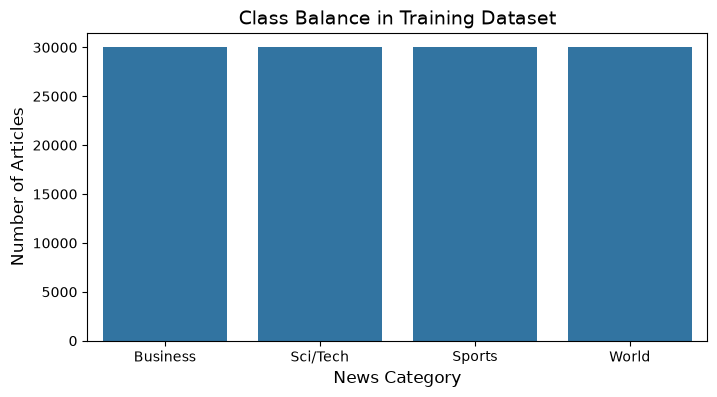

In [4]:
# Plot the distribution of categories
plt.figure(figsize=(8, 4))

ax = sns.countplot(data=train_df, x="Category")
plt.title("Class Balance in Training Dataset", fontsize=14)
plt.xlabel("News Category", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)

plt.show()

Notice that the dataset is **perfectly balanced**: exactly 30,000 articles for each of the 4 categories!
This is great because the model won't be biased towards any single category.


## Step 3: Text Preprocessing (Cleaning the Text)

- HTML tags like `<b>` or `&lt;`
- Broken entity symbols like `#39;` (which is actually an apostrophe `'`)
- Unnecessary backslashes like `early\and`
- Random punctuation like `!!!`, `???`, `$$$`
- News agency tags like `Reuters - ` or `(AP)`

In [5]:
def clean_text(text):
    # 1. Convert to string just in case
    text = str(text)
    
    # 2. Fix broken HTML characters
    text = text.replace("#39;", "'").replace("&amp;", "&").replace("&lt;", "<").replace("&gt;", ">")
    text = text.replace("\\", " ")  # fix backslashes
    
    # 3. Remove HTML tags like <b> or <p>
    text = re.sub(r"<[^>]+>", " ", text)
    
    # 4. Remove website links
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    
    # 5. Remove news agency wire prefixes like 'Reuters - ' or 'AP - '
    text = re.sub(r"^\s*(reuters|ap|afp)\s*[-—–:]\s*", " ", text, flags=re.IGNORECASE)
    
    # 6. Lowercase everything
    text = text.lower()
    
    # 7. Remove punctuation and keep only letters and numbers
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    
    # 8. Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

### Combine Title + Description:
The article **Title** has the most important keywords, and the **Description** provides helpful context.


In [6]:
# Combine Title and Description
X_train_raw = train_df["Title"] + " " + train_df["Description"]
X_test_raw = test_df["Title"] + " " + test_df["Description"]

# Apply our clean_text function
X_train_clean = X_train_raw.apply(clean_text)
X_test_clean = X_test_raw.apply(clean_text)

# Get target category labels
y_train = train_df["Class Index"]
y_test = test_df["Class Index"]

print("Text cleaning complete!")

Text cleaning complete!


## Step 4: Feature Extraction (Converting Text to Numbers)


In [ ]:
tfidf = TfidfVectorizer(
    max_features=15000,     
    ngram_range=(1, 2),      # Single words and 2-word pairs
    stop_words="english",    # Ignore filler words
    sublinear_tf=True        # Scale word counts smoothly
)

print("Converting text to numbers with TF-IDF...")

# 1. Fit and transform the training text
X_train_vec = tfidf.fit_transform(X_train_clean)

# 2. Transform the test text (using the same vocabulary)
X_test_vec = tfidf.transform(X_test_clean)

print(" Feature extraction complete!")

Converting text to numbers with TF-IDF...
 Feature extraction complete!


## Step 5: Train and Compare Machine Learning Models

In [ ]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "Linear SVM": LinearSVC(C=0.5, random_state=42)
}

results = []

# Train and evaluate each model
for name, model in models.items():
    # 1. Train the model
    model.fit(X_train_vec, y_train)
    
    # 2. Make predictions on the test set
    preds = model.predict(X_test_vec)
    
    # 3. Calculate accuracy
    acc = accuracy_score(y_test, preds) * 100
    results.append({"Model": name, "Test Accuracy (%)": round(acc, 2)})
    

# Put results in a nice table
results_df = pd.DataFrame(results)
print(results_df)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


                 Model  Test Accuracy (%)
0  Logistic Regression              91.37
1           Linear SVM              91.82


## Step 6: Detailed Evaluation of the Best Model (Linear SVM)

**Linear SVM** won with **~92% Accuracy**!
Now let's look at its performance in detail:
1. **Classification Report:** Shows Precision, Recall, and F1-Score for each individual category.
2. **Confusion Matrix:** Shows where the model got things right, and which categories it occasionally confused.

In [9]:
# Get predictions from our best model (Linear SVM)
best_model = models["Linear SVM"]
y_pred = best_model.predict(X_test_vec)

# Print the classification report
target_names = [category_map[i] for i in [1, 2, 3, 4]]
print("Detailed Classification Report for Linear SVM:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

Detailed Classification Report for Linear SVM:

              precision    recall  f1-score   support

       World       0.94      0.91      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.89      0.88      0.89      1900
    Sci/Tech       0.89      0.90      0.89      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



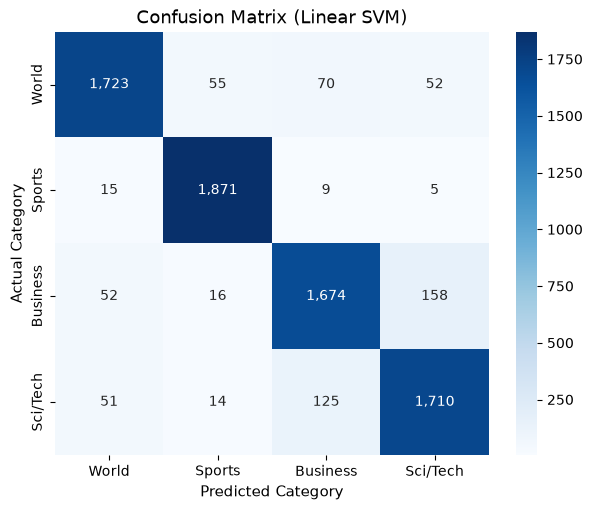

In [10]:
# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3, 4])

plt.figure(figsize=(7, 5.5))
sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Confusion Matrix (Linear SVM)", fontsize=13)
plt.xlabel("Predicted Category", fontsize=11)
plt.ylabel("Actual Category", fontsize=11)
plt.show()